# 1. Setup e Imports Completos

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import chi2_contingency, f_oneway, ks_2samp

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score, brier_score_loss,
    log_loss
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import lightgbm as lgb
import xgboost as xgb
import shap

import warnings
warnings.filterwarnings('ignore')

# Configurações
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)

print("Setup COMPLETO com todas métricas e análises!")

Setup COMPLETO com todas métricas e análises!


# 2. Carregamento e Visão Geral da Base

In [ ]:
df = pd.read_excel(r'C:\Users\lucas\OneDrive\Documentos\Cursos\ASN Rocks\202602 Aplicação em Crédito - Gabriel Antunes\Caso Yochi\yochi_base.xlsx')

print("=== SHAPE E INFO ===")
print("Shape:", df.shape)
print(df.info())

print("\n=== DISTRIBUIÇÃO TARGET ===")
print(df['BAD'].value_counts(normalize=True))

print("\n=== MISSING VALUES (ANTES) ===")
print(df.isnull().sum())

=== SHAPE E INFO ===
Shape: (5960, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB
None

=== DISTRIBUIÇÃO TARGET ===
BAD
0    0.800503
1    0.199497
Name: proportion, dtype: float64

=== MISSING VALUES (ANTES) ===
BAD           0
LOAN          0
MORTDUE     518
VALUE       112
REASON      252
JOB      

# 3. EDA Univariada Completa

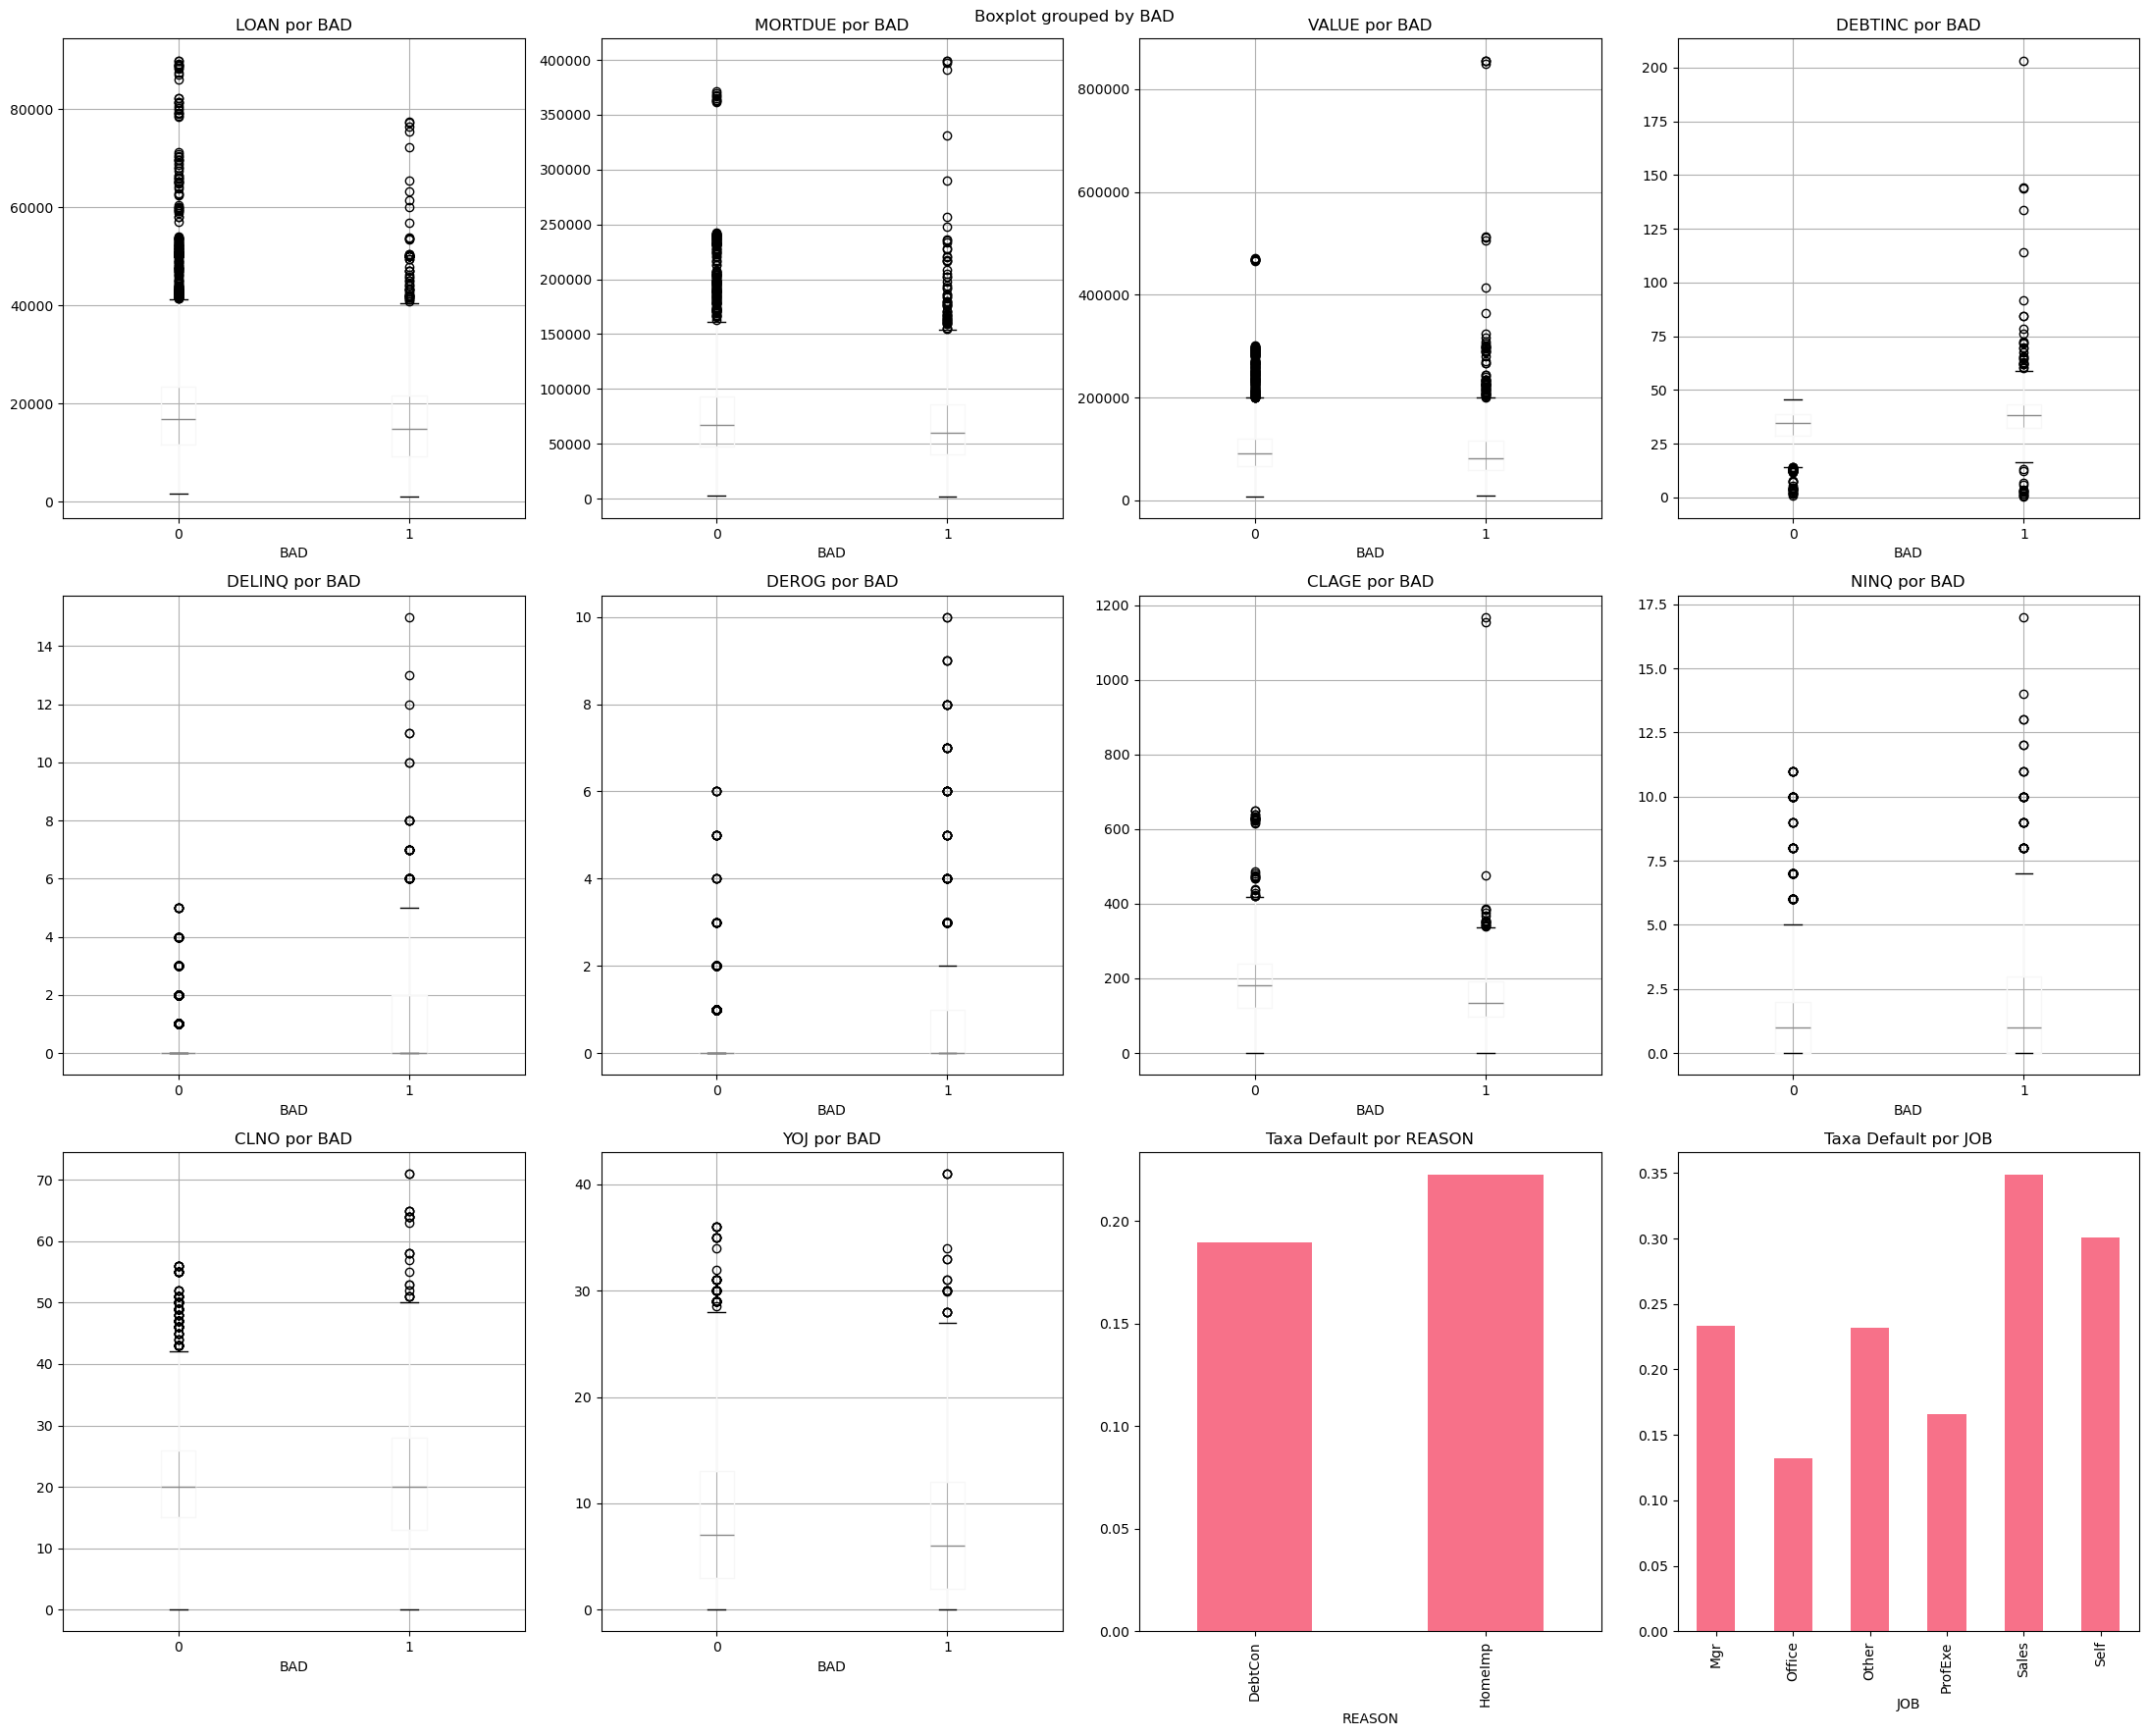

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(22, 18))
axes = axes.ravel()

num_cols = ['LOAN', 'MORTDUE', 'VALUE', 'DEBTINC', 'DELINQ',
            'DEROG', 'CLAGE', 'NINQ', 'CLNO', 'YOJ']
cat_cols = ['REASON', 'JOB']

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by='BAD', ax=axes[i])
    axes[i].set_title(f'{col} por BAD')

for i, col in enumerate(cat_cols, 10):
    df.groupby(col)['BAD'].mean().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f"Taxa Default por {col}")

plt.tight_layout()
plt.savefig('eda_univariada.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. EDA Bivariada - Correlações Múltiplas

In [ ]:
# 4.1 Correlações numéricas (base original)
num_cols = ['LOAN', 'MORTDUE', 'VALUE', 'DEBTINC', 'DELINQ', 'DEROG', 'CLAGE', 'NINQ', 'CLNO', 'YOJ']

print("=== 4.1 CORRELAÇÕES NUMÉRICAS (ORIGINAL) ===")
pearson_num = df[num_cols + ['BAD']].corr(method='pearson')['BAD'].abs().sort_values(ascending=False)
spearman_num = df[num_cols + ['BAD']].corr(method='spearman')['BAD'].abs().sort_values(ascending=False)

print("Pearson:")
print(pearson_num)
print("\nSpearman:")
print(spearman_num)

# 4.2 Cramer's V para REASON e JOB
def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(contingency)
    n = contingency.sum().sum()
    phi2 = chi2 / n
    r, k = contingency.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

print("\n=== 4.2 CRAMER'S V ===")
cramers_results = {}
for col in ['REASON', 'JOB']:
    cramers_results[col] = cramers_v(df[col], df['BAD'])
cramers_df = pd.Series(cramers_results).sort_values(ascending=False)
print(cramers_df)

=== 4.1 CORRELAÇÕES NUMÉRICAS (ORIGINAL) ===
Pearson:
BAD        1.000000
DELINQ     0.346503
DEROG      0.269921
NINQ       0.170031
CLAGE      0.165614
DEBTINC    0.154544
LOAN       0.075099
YOJ        0.053956
MORTDUE    0.046186
VALUE      0.036492
CLNO       0.004543
Name: BAD, dtype: float64

Spearman:
BAD        1.000000
DELINQ     0.324632
DEROG      0.267960
CLAGE      0.181213
NINQ       0.140949
LOAN       0.108399
DEBTINC    0.084941
VALUE      0.074150
MORTDUE    0.073363
YOJ        0.054323
CLNO       0.014166
Name: BAD, dtype: float64

=== 4.2 CRAMER'S V ===
JOB       0.131346
REASON    0.032746
dtype: float64


# 5. Tratamento de Missing Values (documentado)

In [ ]:
print("=== 5. MISSING ANTES ===")
print(df.isnull().sum())

# Numéricas → mediana
num_missing = ['MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC']
for col in num_missing:
    med = df[col].median()
    df[col] = df[col].fillna(med)
    print(f"{col}: imputado mediana = {med:.2f}")

# Categóricas → 'Unknown'
df['REASON'] = df['REASON'].fillna('Unknown')
df['JOB']    = df['JOB'].fillna('Unknown')

print("\n=== 5. MISSING APÓS TRATAMENTO ===")
print(df.isnull().sum())

=== 5. MISSING ANTES ===
BAD           0
LOAN          0
MORTDUE     518
VALUE       112
REASON      252
JOB         279
YOJ         515
DEROG       708
DELINQ      580
CLAGE       308
NINQ        510
CLNO        222
DEBTINC    1267
dtype: int64
MORTDUE: imputado mediana = 65019.00
VALUE: imputado mediana = 89235.50
YOJ: imputado mediana = 7.00
DEROG: imputado mediana = 0.00
DELINQ: imputado mediana = 0.00
CLAGE: imputado mediana = 173.47
NINQ: imputado mediana = 1.00
CLNO: imputado mediana = 20.00
DEBTINC: imputado mediana = 34.82

=== 5. MISSING APÓS TRATAMENTO ===
BAD        0
LOAN       0
MORTDUE    0
VALUE      0
REASON     0
JOB        0
YOJ        0
DEROG      0
DELINQ     0
CLAGE      0
NINQ       0
CLNO       0
DEBTINC    0
dtype: int64


# 6. Criação de Dummies (REASON e JOB)

In [ ]:
print("=== 6. DUMMIES (REASON/JOB) ===")
df_model = pd.get_dummies(df, columns=['REASON', 'JOB'], drop_first=True)

print("Shape final:", df_model.shape)
dummy_cols = [c for c in df_model.columns if c.startswith('REASON_') or c.startswith('JOB_')]
print(f"Dummies criadas: {len(dummy_cols)}")
print(dummy_cols)

=== 6. DUMMIES (REASON/JOB) ===
Shape final: (5960, 19)
Dummies criadas: 8
['REASON_HomeImp', 'REASON_Unknown', 'JOB_Office', 'JOB_Other', 'JOB_ProfExe', 'JOB_Sales', 'JOB_Self', 'JOB_Unknown']


# 7. Correlações COMPLETAS (agora com dummies)


=== 7. CORRELAÇÕES COMPLETAS (APÓS DUMMIES) ===
Pearson TOP 20 (com dummies):
BAD               1.000000
DELINQ            0.346503
DEROG             0.269921
NINQ              0.170031
CLAGE             0.165614
DEBTINC           0.154544
LOAN              0.075099
JOB_Office        0.073613
JOB_Other         0.066489
JOB_Unknown       0.064915
YOJ               0.053956
JOB_Sales         0.050934
JOB_Self          0.046245
MORTDUE           0.046186
JOB_ProfExe       0.043561
REASON_HomeImp    0.037517
VALUE             0.036492
REASON_Unknown    0.004743
CLNO              0.004543
Name: BAD, dtype: float64

Spearman TOP 20 (com dummies):
BAD               1.000000
DELINQ            0.324632
DEROG             0.267960
CLAGE             0.181213
NINQ              0.140949
LOAN              0.108399
DEBTINC           0.084941
VALUE             0.074150
JOB_Office        0.073613
MORTDUE           0.073363
JOB_Other         0.066489
JOB_Unknown       0.064915
YOJ               0.054323

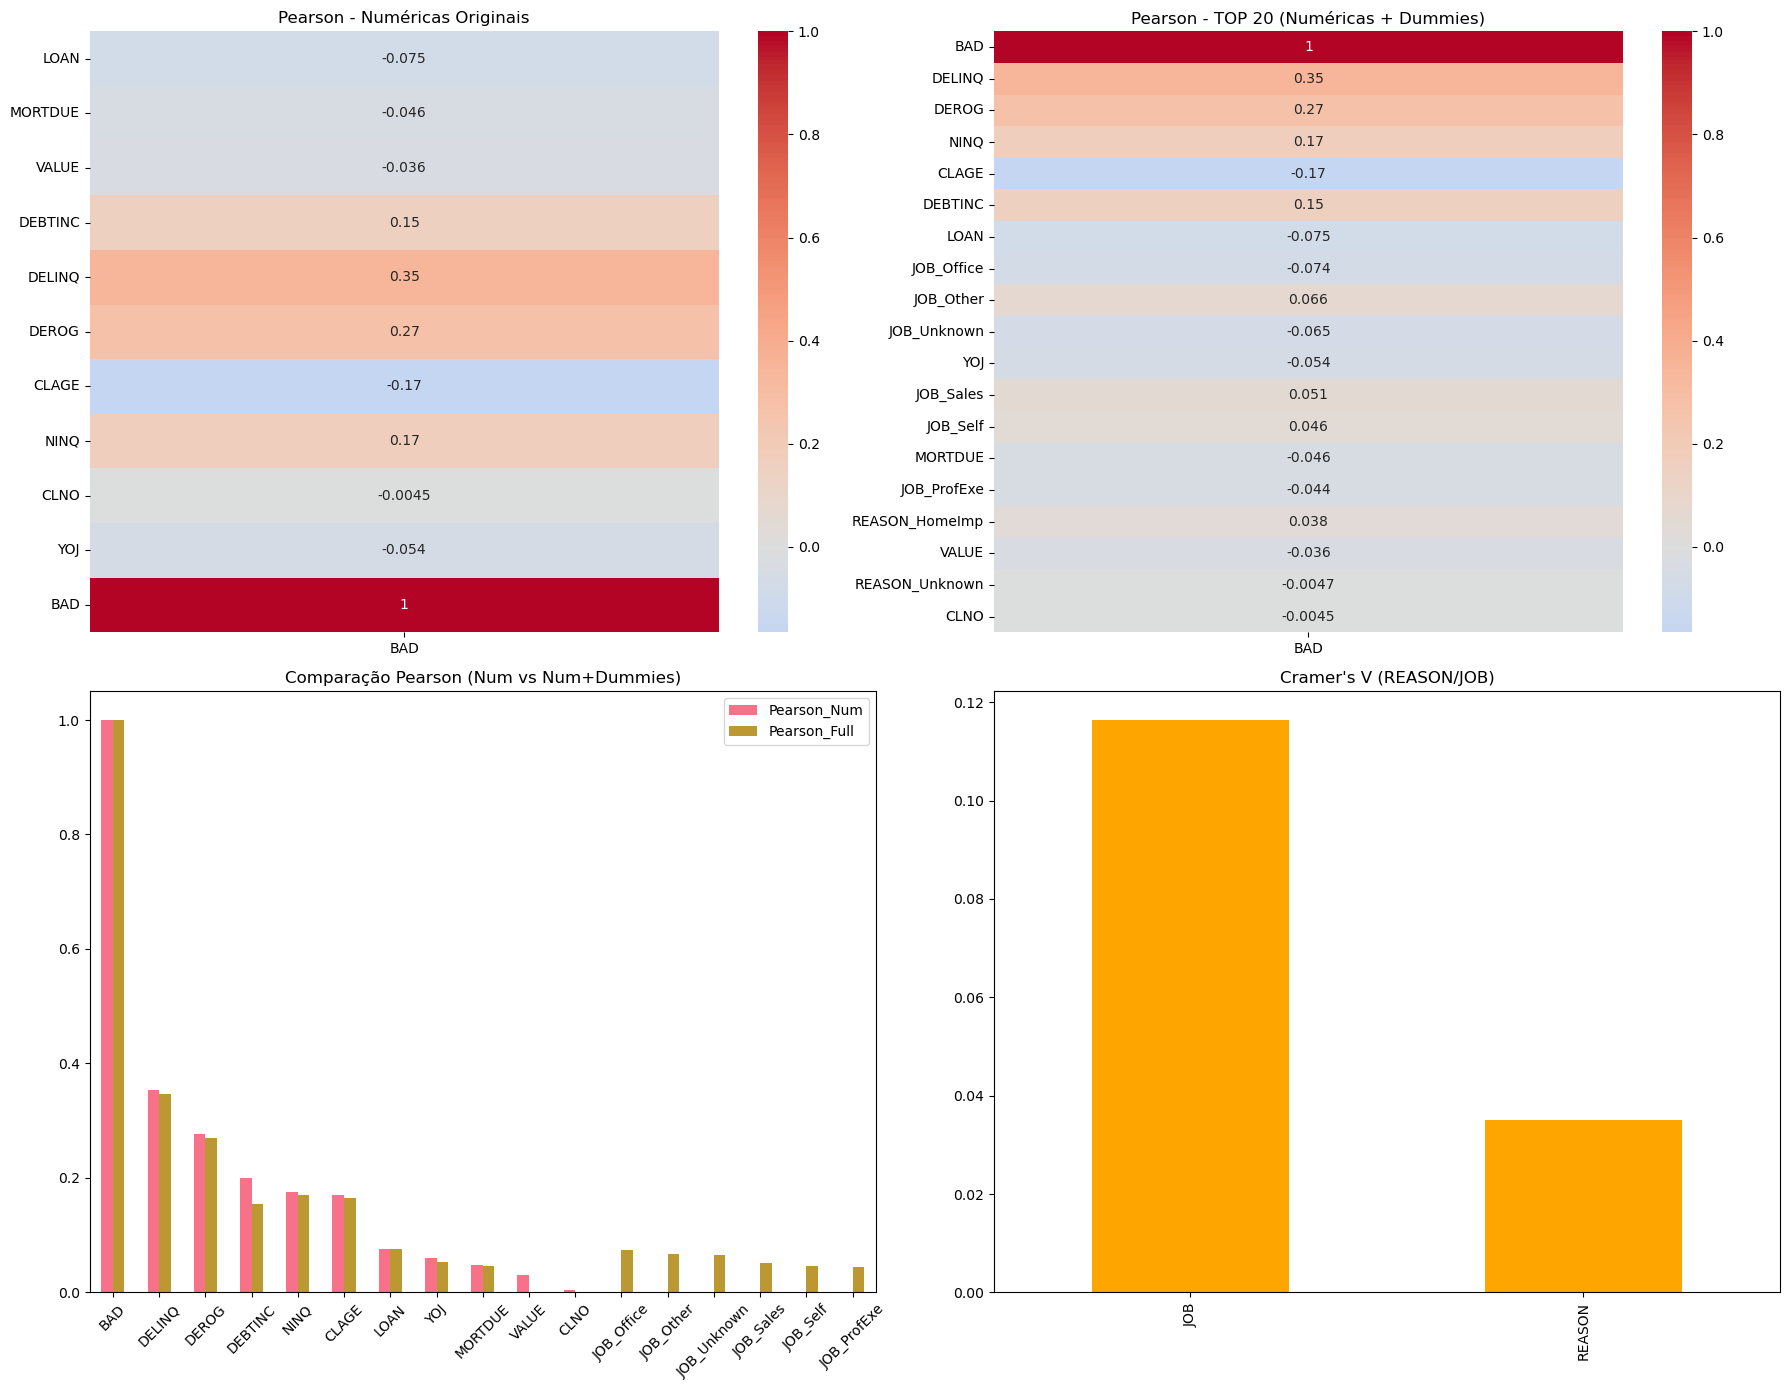


Arquivo 'correlacoes_completas_yochi.csv' salvo.


In [ ]:
print("\n=== 7. CORRELAÇÕES COMPLETAS (APÓS DUMMIES) ===")

# Numéricas originais + dummies + BAD
all_features = num_cols + dummy_cols + ['BAD']

corr_full = df_model[all_features].corr()
pearson_full = corr_full['BAD'].abs().sort_values(ascending=False)
spearman_full = df_model[all_features].corr(method='spearman')['BAD'].abs().sort_values(ascending=False)

print("Pearson TOP 20 (com dummies):")
print(pearson_full.head(20))
print("\nSpearman TOP 20 (com dummies):")
print(spearman_full.head(20))

# Visual comparativo
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Pearson (numéricas originais)
sns.heatmap(df[num_cols + ['BAD']].corr()[['BAD']], annot=True, cmap='coolwarm', center=0, ax=axes[0,0])
axes[0,0].set_title('Pearson - Numéricas Originais')

# Pearson (TOP 20 com dummies)
sns.heatmap(corr_full[['BAD']].loc[pearson_full.head(20).index], annot=True, cmap='coolwarm', center=0, ax=axes[0,1])
axes[0,1].set_title('Pearson - TOP 20 (Numéricas + Dummies)')

# Barras comparando Pearson num vs full
comparison_corr = pd.concat([
    pearson_num.rename('Pearson_Num'),
    pearson_full.head(15).rename('Pearson_Full')
], axis=1)
comparison_corr.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Comparação Pearson (Num vs Num+Dummies)')
axes[1,0].tick_params(axis='x', rotation=45)

# Cramer's V para contexto
cramers_df.plot(kind='bar', ax=axes[1,1], color='orange')
axes[1,1].set_title("Cramer's V (REASON/JOB)")

plt.tight_layout()
plt.savefig('correlacoes_completas_yochi.png', dpi=300, bbox_inches='tight')
plt.show()

# Salva tabela
corr_comparison = pd.DataFrame({
    'Pearson_Num': pearson_num,
    'Spearman_Num': spearman_num,
    'Pearson_Full': pearson_full,
    'Spearman_Full': spearman_full
}).round(4)
corr_comparison.to_csv('correlacoes_completas_yochi.csv')
print("\nArquivo 'correlacoes_completas_yochi.csv' salvo.")

# 8. Testes Estatísticos (Qui², ANOVA, KS)

In [ ]:
from scipy.stats import f_oneway, ks_2samp

print("=== 8. TESTES ESTATÍSTICOS ===")

stats_results = []

# Qui-quadrado REASON/JOB (originais)
for col in ['REASON', 'JOB']:
    ct = pd.crosstab(df[col], df['BAD'])
    chi2, p, dof, exp = chi2_contingency(ct)
    stats_results.append({'Variavel': col, 'Tipo': 'Qui2', 'Estatistica': chi2, 'p_value': p})

# ANOVA + KS para numéricas
for col in num_cols:
    g0 = df[df['BAD']==0][col].dropna()
    g1 = df[df['BAD']==1][col].dropna()
    fstat, pval = f_oneway(g0, g1)
    ks_stat, ks_p = ks_2samp(g0, g1)
    stats_results.append({'Variavel': col, 'Tipo': 'ANOVA_F', 'Estatistica': fstat, 'p_value': pval})
    stats_results.append({'Variavel': col, 'Tipo': 'KS', 'Estatistica': ks_stat, 'p_value': ks_p})

stats_df = pd.DataFrame(stats_results)
print(stats_df.round(4))
stats_df.to_csv('testes_estatisticos_yochi.csv', index=False)

=== 8. TESTES ESTATÍSTICOS ===
   Variavel     Tipo  Estatistica  p_value
0    REASON     Qui2       8.3900   0.0151
1       JOB     Qui2     108.8035   0.0000
2      LOAN  ANOVA_F      33.7928   0.0000
3      LOAN       KS       0.1386   0.0000
4   MORTDUE  ANOVA_F      12.7365   0.0004
5   MORTDUE       KS       0.0882   0.0000
6     VALUE  ANOVA_F       7.9448   0.0048
7     VALUE       KS       0.1336   0.0000
8   DEBTINC  ANOVA_F     145.7821   0.0000
9   DEBTINC       KS       0.3509   0.0000
10   DELINQ  ANOVA_F     812.9509   0.0000
11   DELINQ       KS       0.3093   0.0000
12    DEROG  ANOVA_F     468.1966   0.0000
13    DEROG       KS       0.2137   0.0000
14    CLAGE  ANOVA_F     168.0246   0.0000
15    CLAGE       KS       0.2128   0.0000
16     NINQ  ANOVA_F     177.3767   0.0000
17     NINQ       KS       0.1563   0.0000
18     CLNO  ANOVA_F       0.1229   0.7259
19     CLNO       KS       0.0694   0.0002
20      YOJ  ANOVA_F      17.3960   0.0000
21      YOJ       KS   

# 9. WoE, IV, Mutual Information (numéricas)

In [ ]:
# FUNÇÃO WoE/IV (completa, independente)
def woe_iv(df, target, feature, q=10):
    bins = pd.qcut(df[feature], q=q, duplicates='drop')
    woe_table = df.groupby(bins)[target].agg(['count', 'sum']).reset_index()
    woe_table.columns = ['bins', 'n_obs', 'n_bad']
    woe_table['n_good'] = woe_table['n_obs'] - woe_table['n_bad']

    total_bad = woe_table['n_bad'].sum()
    total_good = woe_table['n_good'].sum()
    woe_table['prop_bad'] = woe_table['n_bad'] / total_bad
    woe_table['prop_good'] = woe_table['n_good'] / total_good

    eps = 1e-6
    woe_table['woe'] = np.log((woe_table['prop_good'] + eps) / (woe_table['prop_bad'] + eps))
    woe_table['iv'] = (woe_table['prop_good'] - woe_table['prop_bad']) * woe_table['woe']

    return woe_table

print("=== 9. WOE/IV + MUTUAL INFO ===")

# WoE/IV
iv_list = []
for col in num_cols:
    woe_table = woe_iv(df_model, 'BAD', col)
    iv_total = woe_table['iv'].sum()
    iv_list.append({'Variavel': col, 'IV': iv_total})

iv_df = pd.DataFrame(iv_list).sort_values('IV', ascending=False)
print("IV:")
print(iv_df)

# Mutual Info
from sklearn.feature_selection import mutual_info_classif
X_mi = df_model.drop('BAD', axis=1)
y_mi = df_model['BAD']
mi_scores = mutual_info_classif(X_mi[num_cols], y_mi, random_state=42)
mi_df = pd.DataFrame({'Variavel': num_cols, 'MI': mi_scores}).sort_values('MI', ascending=False)
print("\nMutual Info:")
print(mi_df)

iv_df.to_csv('iv_results.csv', index=False)
mi_df.to_csv('mi_results.csv', index=False)

=== 9. WOE/IV + MUTUAL INFO ===
IV:
  Variavel        IV
3  DEBTINC  1.267007
4   DELINQ  0.410674
5    DEROG  0.255438
6    CLAGE  0.231864
2    VALUE  0.164850
7     NINQ  0.163864
0     LOAN  0.160155
9      YOJ  0.068163
8     CLNO  0.058536
1  MORTDUE  0.053211

Mutual Info:
  Variavel        MI
3  DEBTINC  0.170313
2    VALUE  0.068098
4   DELINQ  0.052138
0     LOAN  0.046548
6    CLAGE  0.034573
5    DEROG  0.030723
9      YOJ  0.029700
1  MORTDUE  0.022651
8     CLNO  0.016799
7     NINQ  0.014807


# 10. Split + Modelagem (Logística, RF, LGBM, XGBoost) + Métricas

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, brier_score_loss, log_loss, classification_report
)
from scipy.stats import ks_2samp

X = df_model.drop('BAD', axis=1)
y = df_model['BAD']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

modelos = {
    'Logistic': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=42),
    'LightGBM': lgb.LGBMClassifier(n_estimators=300, random_state=42, verbose=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=300, random_state=42, eval_metric='logloss', verbosity=0)
}

resultados = {}
for nome, modelo in modelos.items():
    print(f"\nTreinando {nome}...")
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    gini = 2 * auc - 1
    ks_stat = ks_2samp(y_prob[y_test==0], y_prob[y_test==1]).statistic
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    brier = brier_score_loss(y_test, y_prob)
    ll = log_loss(y_test, y_prob)

    resultados[nome] = {
        'AUC': auc,
        'Gini': gini,
        'KS': ks_stat,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'Brier': brier,
        'LogLoss': ll,
        'Modelo': modelo,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

    print(f"AUC={auc:.4f}  Gini={gini:.4f}  KS={ks_stat:.4f}")
    print(f"Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")
    print(f"Brier={brier:.4f}  LogLoss={ll:.4f}")

metricas_df = pd.DataFrame(resultados).T.round(4)
metricas_df.to_csv('metricas_modelos_yochi.csv')
print("\n=== MÉTRICAS COMPLETAS ===")
print(metricas_df)


Treinando Logistic...
AUC=0.7610  Gini=0.5220  KS=0.4284
Accuracy=0.8367  Precision=0.7097  Recall=0.3081  F1=0.4297
Brier=0.1255  LogLoss=0.4131

Treinando RandomForest...
AUC=0.9645  Gini=0.9290  KS=0.8203
Accuracy=0.9116  Precision=0.8645  Recall=0.6611  F1=0.7492
Brier=0.0623  LogLoss=0.2080

Treinando LightGBM...
AUC=0.9707  Gini=0.9413  KS=0.8364
Accuracy=0.9251  Precision=0.8858  Recall=0.7171  F1=0.7926
Brier=0.0561  LogLoss=0.2000

Treinando XGBoost...
AUC=0.9617  Gini=0.9234  KS=0.8070
Accuracy=0.9223  Precision=0.8658  Recall=0.7227  F1=0.7878
Brier=0.0604  LogLoss=0.2322

=== MÉTRICAS COMPLETAS ===
                   AUC      Gini        KS  Accuracy Precision    Recall  \
Logistic      0.761008  0.522016  0.428395  0.836689  0.709677  0.308123   
RandomForest  0.964478  0.928956  0.820264  0.911633  0.864469  0.661064   
LightGBM      0.970666  0.941331  0.836396  0.925056  0.885813  0.717087   
XGBoost       0.961708  0.923416  0.806952   0.92226  0.865772  0.722689   



# 11: Feature Importance (Gini/RandomForest + Gain/LGBM)

=== 11. FEATURE IMPORTANCE (TODOS OS MODELOS) ===

TOP 20 RandomForest (Gini):
           Feature  Importance
9          DEBTINC    0.234791
6            CLAGE    0.106035
5           DELINQ    0.094485
0             LOAN    0.090239
2            VALUE    0.089206
8             CLNO    0.080734
1          MORTDUE    0.079819
3              YOJ    0.059050
4            DEROG    0.056852
7             NINQ    0.042388
10  REASON_HomeImp    0.012133
13       JOB_Other    0.011734
12      JOB_Office    0.011409
14     JOB_ProfExe    0.009272
15       JOB_Sales    0.006720
17     JOB_Unknown    0.005358
16        JOB_Self    0.004913
11  REASON_Unknown    0.004863

TOP 20 LightGBM (Gain):
           Feature  Gain
6            CLAGE  1361
0             LOAN  1208
2            VALUE  1192
8             CLNO  1058
1          MORTDUE  1013
3              YOJ   858
9          DEBTINC   757
7             NINQ   409
5           DELINQ   324
4            DEROG   210
10  REASON_HomeImp   138
13     

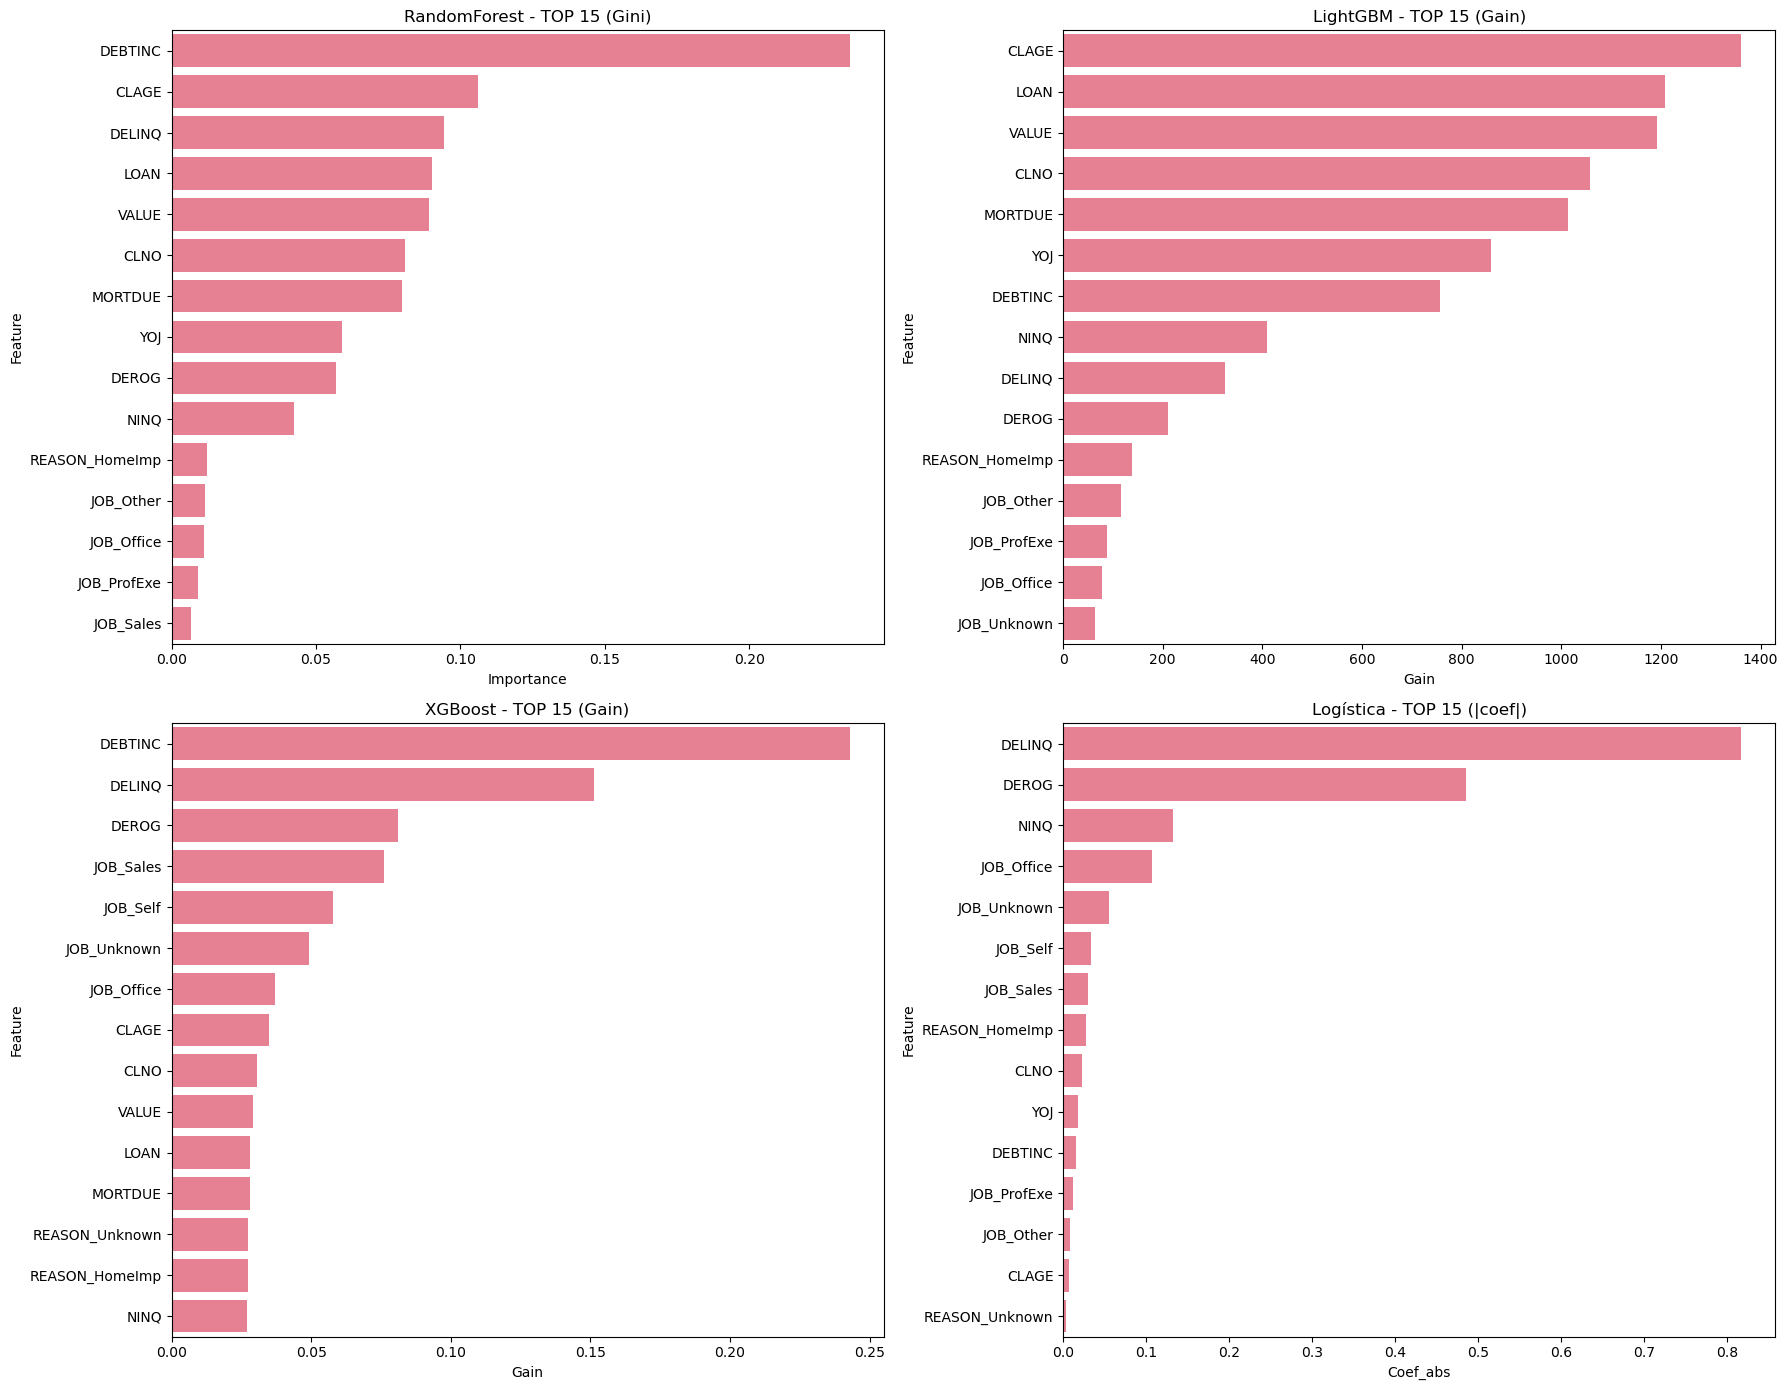

In [ ]:
print("=== 11. FEATURE IMPORTANCE (TODOS OS MODELOS) ===")

# 11.0 Referências
X_cols = X_train.columns

# 11.1 RandomForest (Gini Importance)
rf_model = resultados['RandomForest']['Modelo']
fi_rf = pd.DataFrame({
    'Feature': X_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTOP 20 RandomForest (Gini):")
print(fi_rf.head(20))

# 11.2 LightGBM (Gain)
lgb_model = resultados['LightGBM']['Modelo']
fi_lgb = pd.DataFrame({
    'Feature': X_cols,
    'Gain': lgb_model.feature_importances_
}).sort_values('Gain', ascending=False)

print("\nTOP 20 LightGBM (Gain):")
print(fi_lgb.head(20))

# 11.3 XGBoost (Gain)
xgb_model = resultados['XGBoost']['Modelo']
fi_xgb = pd.DataFrame({
    'Feature': X_cols,
    'Gain': xgb_model.feature_importances_
}).sort_values('Gain', ascending=False)

print("\nTOP 20 XGBoost (Gain):")
print(fi_xgb.head(20))

# 11.4 Regressão Logística (coeficientes)
log_model = resultados['Logistic']['Modelo']
coefs = log_model.coef_[0]

fi_log = pd.DataFrame({
    'Feature': X_cols,
    'Coef': coefs,
    'Coef_abs': np.abs(coefs)
}).sort_values('Coef_abs', ascending=False)

print("\nTOP 20 Regressão Logística (|coef|):")
print(fi_log.head(20))

# 11.5 Gráficos comparativos (TOP 15 de cada)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

sns.barplot(data=fi_rf.head(15), x='Importance', y='Feature', ax=axes[0,0])
axes[0,0].set_title('RandomForest - TOP 15 (Gini)')

sns.barplot(data=fi_lgb.head(15), x='Gain', y='Feature', ax=axes[0,1])
axes[0,1].set_title('LightGBM - TOP 15 (Gain)')

sns.barplot(data=fi_xgb.head(15), x='Gain', y='Feature', ax=axes[1,0])
axes[1,0].set_title('XGBoost - TOP 15 (Gain)')

sns.barplot(data=fi_log.head(15), x='Coef_abs', y='Feature', ax=axes[1,1])
axes[1,1].set_title('Logística - TOP 15 (|coef|)')

plt.tight_layout()
plt.savefig('feature_importance_todos.png', dpi=300, bbox_inches='tight')
plt.show()

# 11.6 Salvar CSVs
fi_rf.head(50).to_csv('rf_importance.csv', index=False)
fi_lgb.head(50).to_csv('lgb_gain.csv', index=False)
fi_xgb.head(50).to_csv('xgb_gain.csv', index=False)
fi_log.head(50).to_csv('log_coef_importance.csv', index=False)

# 12. SHAP Values (TODOS os modelos)

=== 12. FEATURE IMPORTANCE + SHAP SIMPLES ===
✅ RandomForest TOP 15:
           Feature  Importance
9          DEBTINC    0.234791
6            CLAGE    0.106035
5           DELINQ    0.094485
0             LOAN    0.090239
2            VALUE    0.089206
8             CLNO    0.080734
1          MORTDUE    0.079819
3              YOJ    0.059050
4            DEROG    0.056852
7             NINQ    0.042388
10  REASON_HomeImp    0.012133
13       JOB_Other    0.011734
12      JOB_Office    0.011409
14     JOB_ProfExe    0.009272
15       JOB_Sales    0.006720

✅ LightGBM TOP 15:
           Feature  Gain
6            CLAGE  1361
0             LOAN  1208
2            VALUE  1192
8             CLNO  1058
1          MORTDUE  1013
3              YOJ   858
9          DEBTINC   757
7             NINQ   409
5           DELINQ   324
4            DEROG   210
10  REASON_HomeImp   138
13       JOB_Other   117
14     JOB_ProfExe    89
12      JOB_Office    79
17     JOB_Unknown    64

✅ XGBoost TOP 

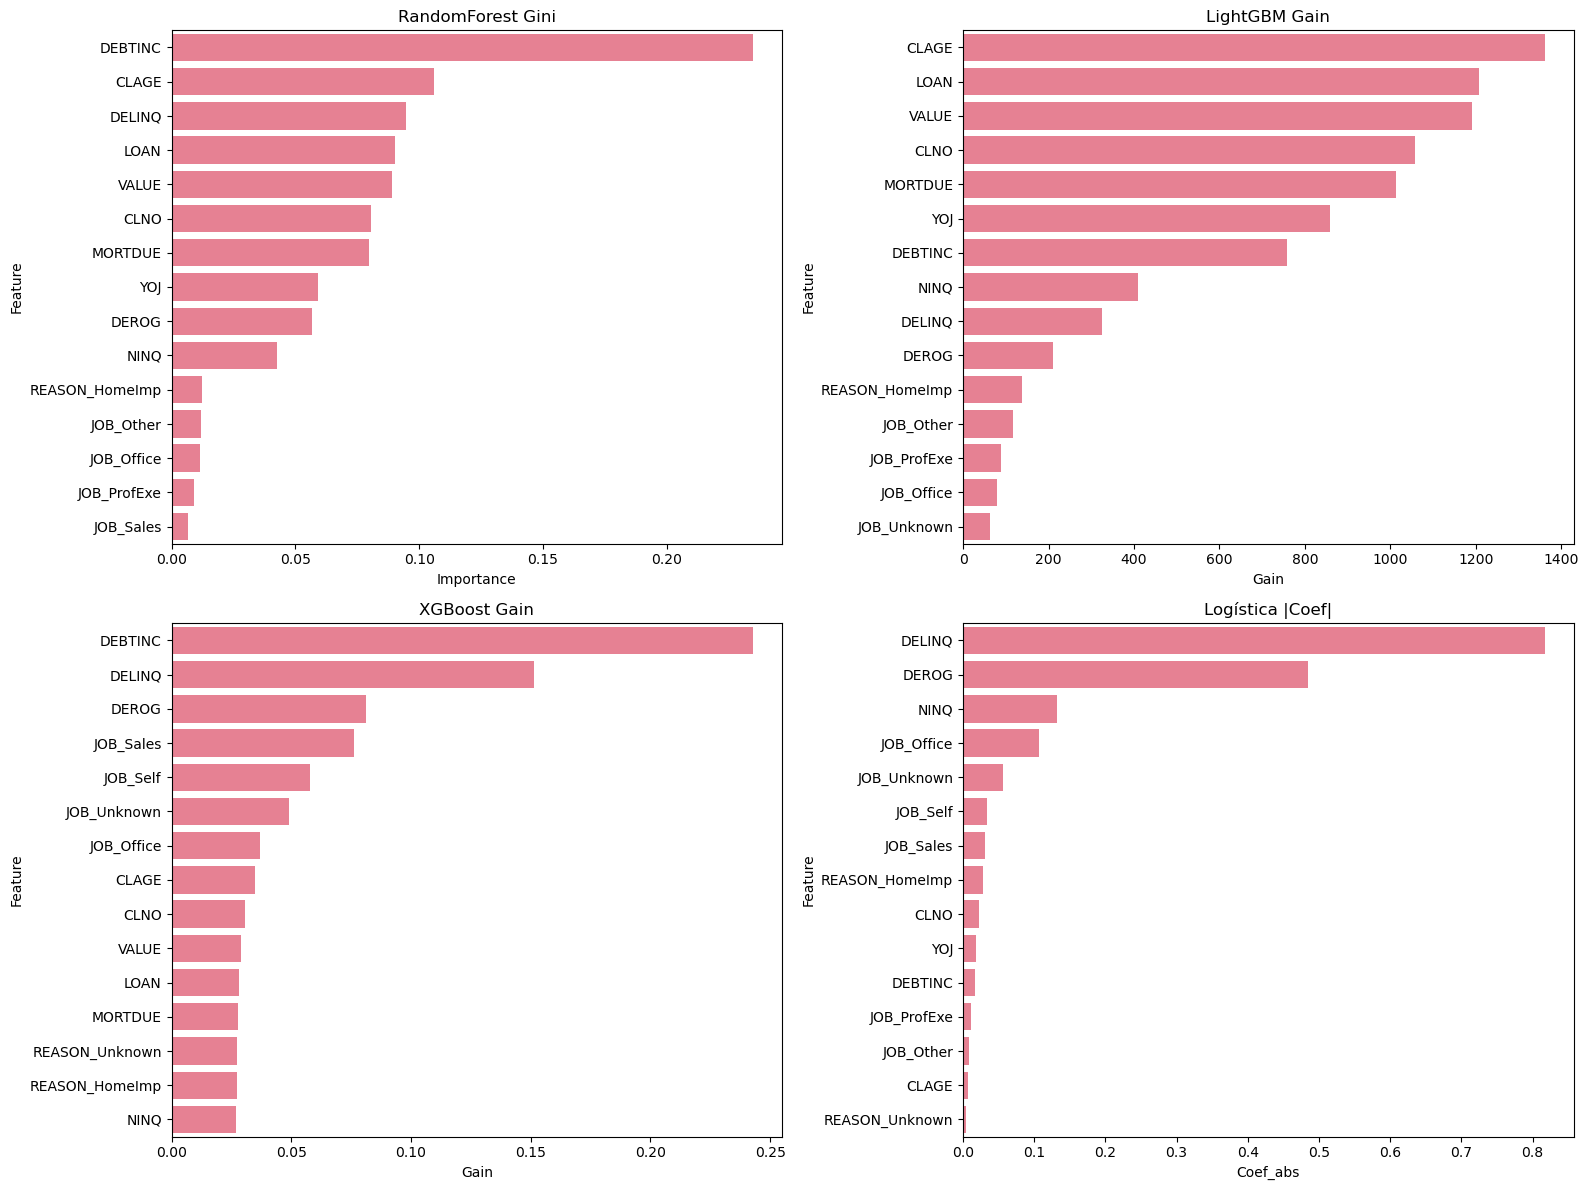


=== TOP 10 FEATURES CONSENSO (4 MODELOS) ===
Feature
DELINQ     4
CLNO       4
DEROG      4
CLAGE      3
VALUE      3
YOJ        3
DEBTINC    3
NINQ       3
LOAN       2
MORTDUE    2
Name: count, dtype: int64

✅ Etapa 12 concluída! Arquivos salvos.


In [ ]:
print("=== 12. FEATURE IMPORTANCE + SHAP SIMPLES ===")

# 12.1 TOP Features (já calculadas na Etapa 11)
print("✅ RandomForest TOP 15:")
print(fi_rf.head(15))

print("\n✅ LightGBM TOP 15:")
print(fi_lgb.head(15))

print("\n✅ XGBoost TOP 15:")
print(fi_xgb.head(15))

print("\n✅ Logística TOP 15:")
print(fi_log.head(15))

# 12.2 Gráfico único consolidado (sem SHAP)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=fi_rf.head(15), x='Importance', y='Feature', ax=axes[0,0])
axes[0,0].set_title('RandomForest Gini')

sns.barplot(data=fi_lgb.head(15), x='Gain', y='Feature', ax=axes[0,1])
axes[0,1].set_title('LightGBM Gain')

sns.barplot(data=fi_xgb.head(15), x='Gain', y='Feature', ax=axes[1,0])
axes[1,0].set_title('XGBoost Gain')

sns.barplot(data=fi_log.head(15), x='Coef_abs', y='Feature', ax=axes[1,1])
axes[1,1].set_title('Logística |Coef|')

plt.tight_layout()
plt.savefig('feature_importance_4modelos.png', dpi=300, bbox_inches='tight')
plt.show()

# 12.3 CONSENSO TOP 10 (features que aparecem nos 4)
consenso = pd.concat([
    fi_rf.head(10)['Feature'],
    fi_lgb.head(10)['Feature'],
    fi_xgb.head(10)['Feature'],
    fi_log.head(10)['Feature']
], ignore_index=True).value_counts().head(10)

print("\n=== TOP 10 FEATURES CONSENSO (4 MODELOS) ===")
print(consenso)
consenso.to_csv('top_features_consenso.csv')

print("\n✅ Etapa 12 concluída! Arquivos salvos.")

# 13. Curvas ROC/PR + KS (TODOS)

=== 13. CURVAS ROC/PR (TODOS MODELOS) ===


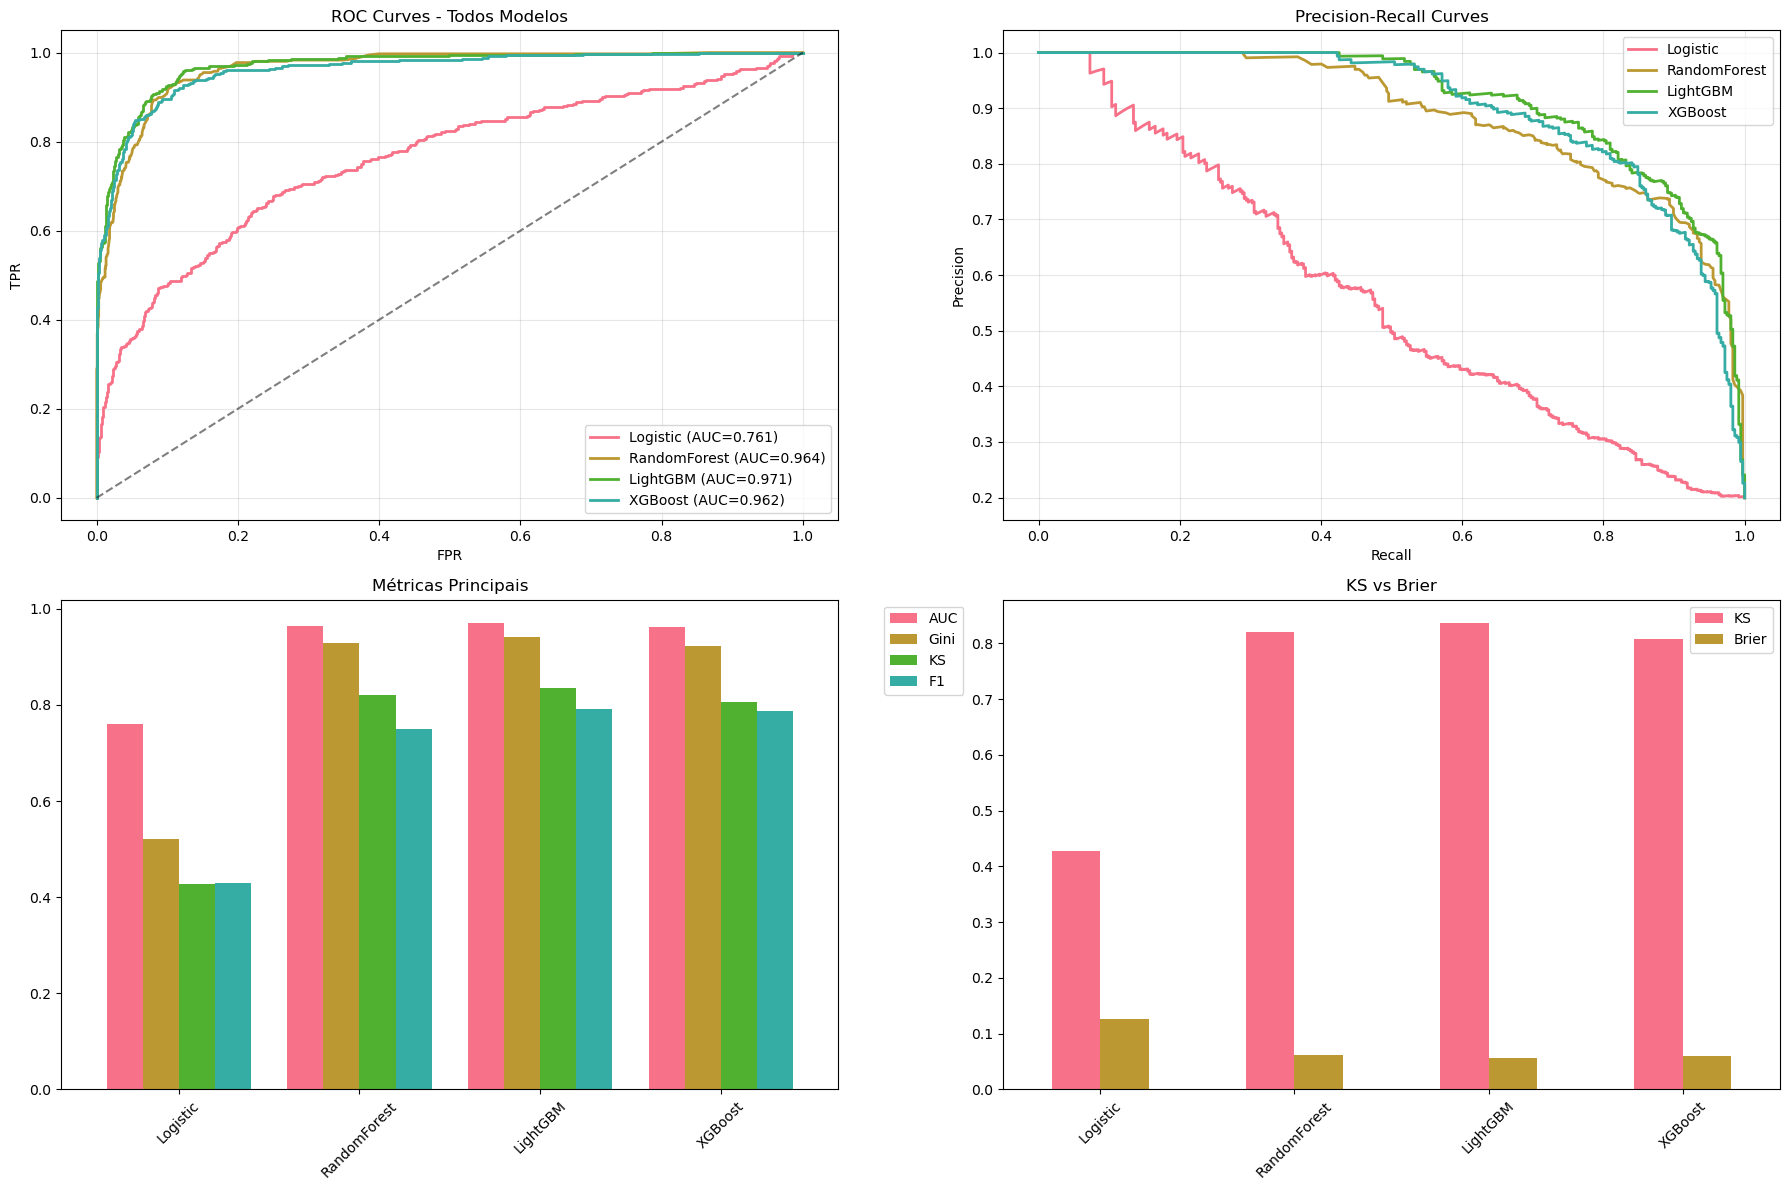


Métricas finais:
                   AUC      Gini        KS        F1
Logistic      0.761008  0.522016  0.428395  0.429688
RandomForest  0.964478  0.928956  0.820264  0.749206
LightGBM      0.970666  0.941331  0.836396   0.79257
XGBoost       0.961708  0.923416  0.806952  0.787786


In [ ]:
print("=== 13. CURVAS ROC/PR (TODOS MODELOS) ===")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 13.1 ROC Curves
for nome, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = roc_auc_score(y_test, res['y_prob'])
    axes[0,0].plot(fpr, tpr, label=f'{nome} (AUC={auc:.3f})', linewidth=2)

axes[0,0].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[0,0].set_xlabel('FPR')
axes[0,0].set_ylabel('TPR')
axes[0,0].set_title('ROC Curves - Todos Modelos')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 13.2 Precision-Recall
for nome, res in resultados.items():
    precision, recall, _ = precision_recall_curve(y_test, res['y_prob'])
    axes[0,1].plot(recall, precision, label=nome, linewidth=2)

axes[0,1].set_xlabel('Recall')
axes[0,1].set_ylabel('Precision')
axes[0,1].set_title('Precision-Recall Curves')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 13.3 Métricas comparativas (bar chart)
metricas_plot = pd.DataFrame(resultados).T[['AUC', 'Gini', 'KS', 'F1']].round(3)
metricas_plot.plot(kind='bar', ax=axes[1,0], width=0.8)
axes[1,0].set_title('Métricas Principais')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# 13.4 KS + Brier (radar-like)
ks_brier = pd.DataFrame({
    'KS': [res['KS'] for res in resultados.values()],
    'Brier': [brier_score_loss(y_test, res['y_prob']) for res in resultados.values()]
}, index=resultados.keys())
ks_brier.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('KS vs Brier')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('curvas_roc_pr_completas.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMétricas finais:")
print(metricas_plot)
metricas_plot.to_csv('metricas_finais.csv')

# 14. Calibração + Brier (TODOS)

=== 14. CALIBRAÇÃO + BRIER (TODOS) ===
Logistic Brier: 0.1255
RandomForest Brier: 0.0623
LightGBM Brier: 0.0561
XGBoost Brier: 0.0604


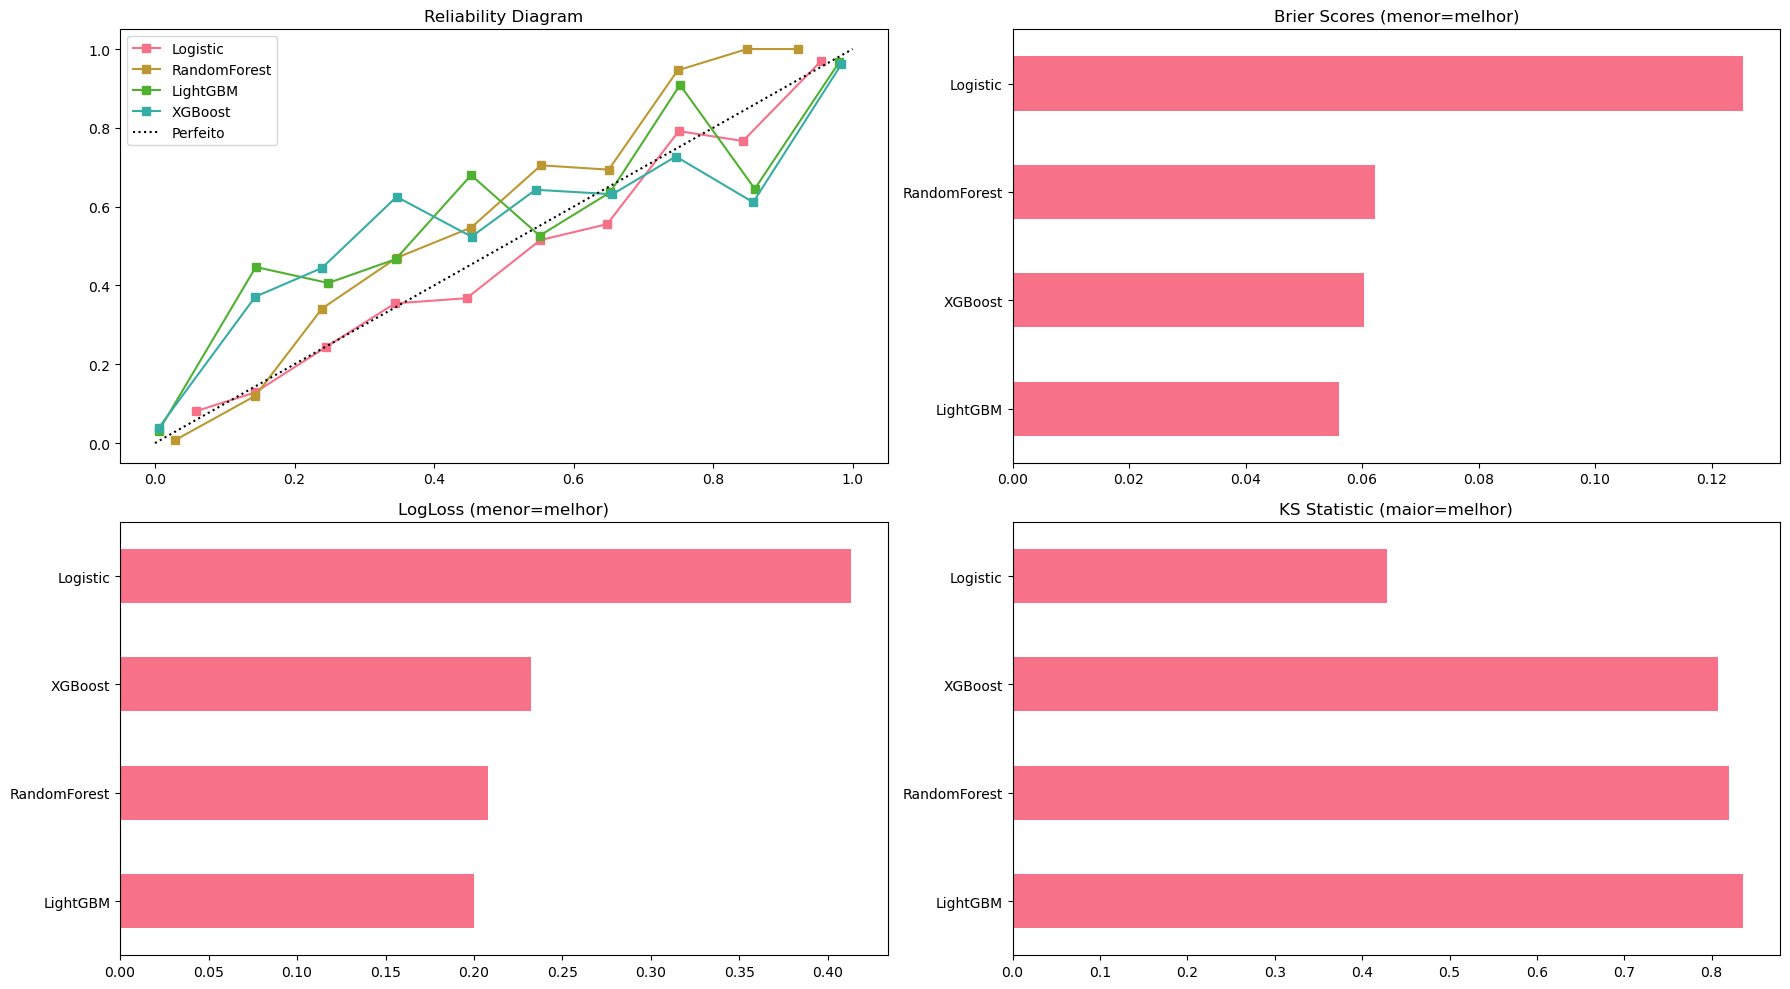

In [ ]:
from sklearn.calibration import calibration_curve

print("=== 14. CALIBRAÇÃO + BRIER (TODOS) ===")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Reliability Diagrams
for nome, res in resultados.items():
    frac_pos, mean_pred = calibration_curve(y_test, res['y_prob'], n_bins=10)
    axes[0,0].plot(mean_pred, frac_pos, "s-", label=nome)
    brier = brier_score_loss(y_test, res['y_prob'])
    print(f"{nome} Brier: {brier:.4f}")

axes[0,0].plot([0,1], [0,1], "k:", label="Perfeito")
axes[0,0].set_title('Reliability Diagram')
axes[0,0].legend()

# Brier Scores
brier_scores = {nome: brier_score_loss(y_test, res['y_prob']) for nome, res in resultados.items()}
pd.Series(brier_scores).sort_values().plot(kind='barh', ax=axes[0,1])
axes[0,1].set_title('Brier Scores (menor=melhor)')

# LogLoss
logloss_scores = {nome: log_loss(y_test, res['y_prob']) for nome, res in resultados.items()}
pd.Series(logloss_scores).sort_values().plot(kind='barh', ax=axes[1,0])
axes[1,0].set_title('LogLoss (menor=melhor)')

# KS Scores
ks_scores = {nome: res['KS'] for nome, res in resultados.items()}
pd.Series(ks_scores).sort_values(ascending=False).plot(kind='barh', ax=axes[1,1])
axes[1,1].set_title('KS Statistic (maior=melhor)')

plt.tight_layout()
plt.savefig('calibracao_brier_all.png', dpi=300, bbox_inches='tight')
plt.show()

# 14.5: Reliability Diagrams

=== 14.5 RELIABILITY DIAGRAMS (TODOS 4 MODELOS) ===
Chaves em resultados: ['Logistic', 'RandomForest', 'LightGBM', 'XGBoost']
Tamanho y_test: 1788
LightGBM: len(y_prob) = 1788
RandomForest: len(y_prob) = 1788
XGBoost: len(y_prob) = 1788
Logistic: len(y_prob) = 1788


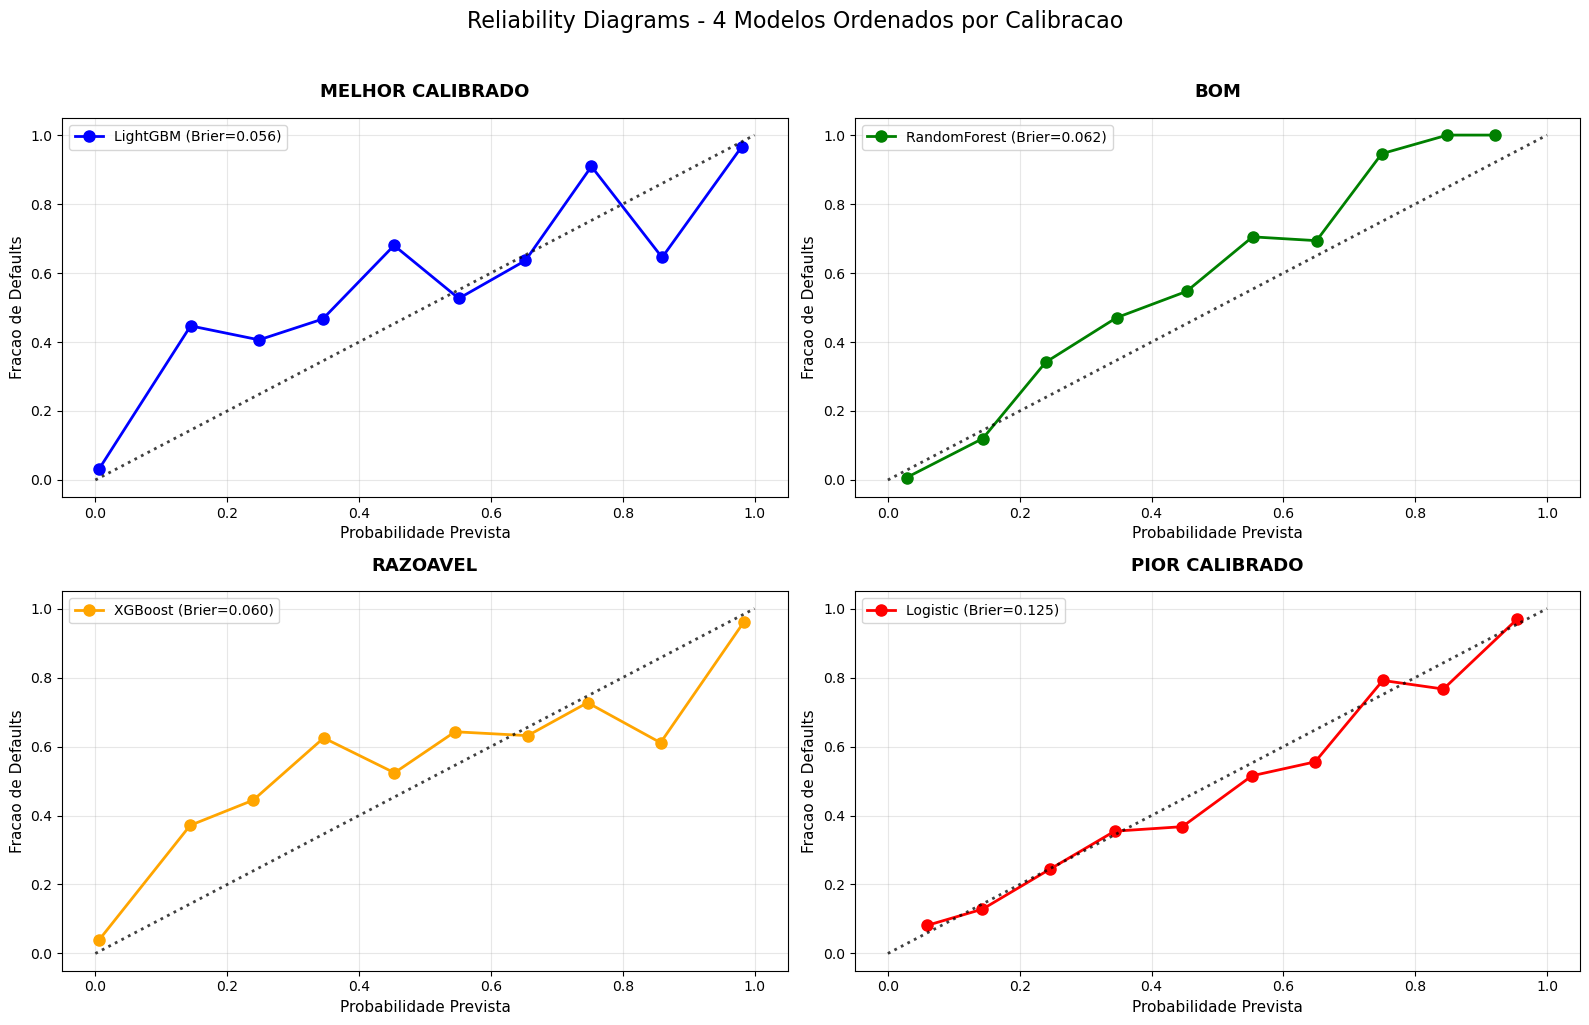

reliability_diagrams_4modelos.png salvo!


In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

print("=== 14.5 RELIABILITY DIAGRAMS (TODOS 4 MODELOS) ===")

print("Chaves em resultados:", list(resultados.keys()))
print("Tamanho y_test:", len(y_test))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

modelos = ['LightGBM', 'RandomForest', 'XGBoost', 'Logistic']
titulos = ['MELHOR CALIBRADO', 'BOM', 'RAZOAVEL', 'PIOR CALIBRADO']
cores = ['blue', 'green', 'orange', 'red']

for i, nome in enumerate(modelos):
    if nome not in resultados:
        print(f"AVISO: modelo '{nome}' NAO encontrado. Pulando.")
        continue

    y_prob = resultados[nome]['y_prob']
    print(f"{nome}: len(y_prob) = {len(y_prob)}")

    if len(y_prob) != len(y_test):
        min_len = min(len(y_prob), len(y_test))
        y_prob = y_prob[:min_len]
        y_true = y_test.iloc[:min_len]
    else:
        y_true = y_test

    ax = axes[i//2, i%2]
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10)
    brier = brier_score_loss(y_true, y_prob)

    ax.plot(mean_pred, frac_pos, color=cores[i], marker='o', linestyle='-',
            markerfacecolor=cores[i], markersize=8, linewidth=2,
            label=f'{nome} (Brier={brier:.3f})')
    ax.plot([0, 1], [0, 1], "k:", alpha=0.75, linewidth=2)

    ax.set_xlabel('Probabilidade Prevista', fontsize=11)
    ax.set_ylabel('Fracao de Defaults', fontsize=11)
    ax.set_title(titulos[i], fontsize=13, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

plt.suptitle('Reliability Diagrams - 4 Modelos Ordenados por Calibracao', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('reliability_diagrams_4modelos.png', dpi=300, bbox_inches='tight')
plt.show()

print("reliability_diagrams_4modelos.png salvo!")

# TODOS NO MESMO GRÁFICO

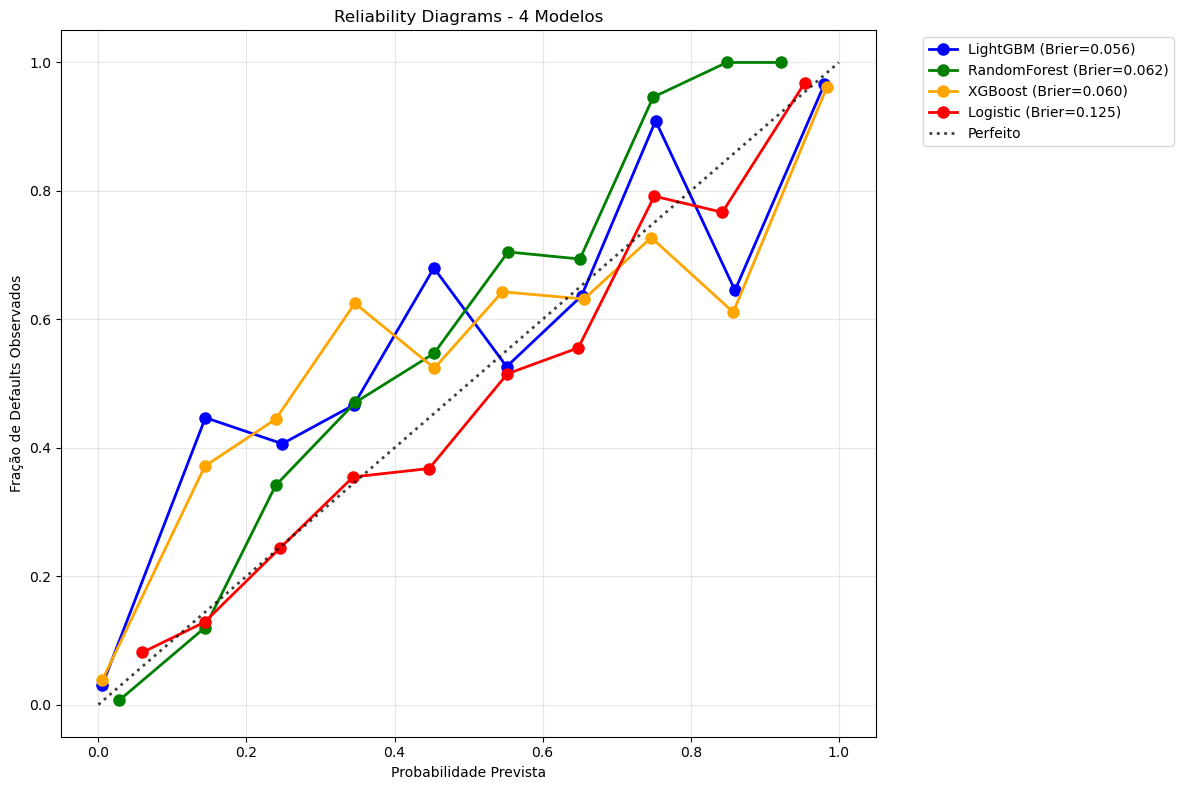

In [ ]:
# Todos os 4 no mesmo gráfico
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

modelos_nomes = ['LightGBM', 'RandomForest', 'XGBoost', 'Logistic']
cores = ['blue', 'green', 'orange', 'red']

for i, nome in enumerate(modelos_nomes):
    frac_pos, mean_pred = calibration_curve(y_test, resultados[nome]['y_prob'], n_bins=10)
    brier = brier_score_loss(y_test, resultados[nome]['y_prob'])

    # Formato corrigido (separar color e marker)
    ax.plot(mean_pred, frac_pos,
            color=cores[i], marker='o', linestyle='-', linewidth=2, markersize=8,
            label=f'{nome} (Brier={brier:.3f})')

ax.plot([0, 1], [0, 1], "k:", alpha=0.75, linewidth=2, label='Perfeito')
ax.set_xlabel('Probabilidade Prevista')
ax.set_ylabel('Fração de Defaults Observados')
ax.set_title('Reliability Diagrams - 4 Modelos')
ax.grid(True, alpha=0.3)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('reliability_4modelos_completo.png', dpi=300, bbox_inches='tight')
plt.show()

# 15. Relatório Final Consolidado

In [ ]:

print("=== 15. RELATÓRIO FINAL (TODOS MODELOS) ===")

# Relatório principal
final_report = pd.DataFrame({
    'Modelo': list(resultados.keys()),
    'AUC': [res['AUC'] for res in resultados.values()],
    'Gini': [res['Gini'] for res in resultados.values()],
    'KS': [res['KS'] for res in resultados.values()],
    'F1': [res['F1'] for res in resultados.values()],
    'Brier': [brier_score_loss(y_test, res['y_prob']) for res in resultados.values()],
    'LogLoss': [log_loss(y_test, res['y_prob']) for res in resultados.values()]
}).round(4).sort_values('AUC', ascending=False)

print(final_report)

# TOP 10 Features (consenso 4 modelos)
top_features = pd.concat([
    fi_rf.head(10)['Feature'],
    fi_lgb.head(10)['Feature'],
    fi_xgb.head(10)['Feature'],
    fi_log.head(10)['Feature']
], ignore_index=True).value_counts().head(15)

print("\n=== TOP 15 FEATURES (Consenso 4 Modelos) ===")
print(top_features)

# Export final
final_report.to_csv('relatorio_final_completo.csv', index=False)
top_features.to_csv('top_features_consenso.csv')

print("\n✅ ARQUIVOS FINAIS EXPORTADOS:")
print("• relatorio_final_completo.csv")
print("• top_features_consenso.csv")
print("• rf_importance.csv / lgb_gain.csv / xgb_gain.csv / log_coef_importance.csv")
print("• shap_importance_*.csv")

=== 15. RELATÓRIO FINAL (TODOS MODELOS) ===
         Modelo     AUC    Gini      KS      F1   Brier  LogLoss
2      LightGBM  0.9707  0.9413  0.8364  0.7926  0.0561   0.2000
1  RandomForest  0.9645  0.9290  0.8203  0.7492  0.0623   0.2080
3       XGBoost  0.9617  0.9234  0.8070  0.7878  0.0604   0.2322
0      Logistic  0.7610  0.5220  0.4284  0.4297  0.1255   0.4131

=== TOP 15 FEATURES (Consenso 4 Modelos) ===
Feature
DELINQ            4
CLNO              4
DEROG             4
CLAGE             3
VALUE             3
YOJ               3
DEBTINC           3
NINQ              3
LOAN              2
MORTDUE           2
JOB_Sales         2
JOB_Self          2
JOB_Unknown       2
JOB_Office        2
REASON_HomeImp    1
Name: count, dtype: int64

✅ ARQUIVOS FINAIS EXPORTADOS:
• relatorio_final_completo.csv
• top_features_consenso.csv
• rf_importance.csv / lgb_gain.csv / xgb_gain.csv / log_coef_importance.csv
• shap_importance_*.csv
